# Problem 2.b: Fine-tuning Only the Head

**Objective:** Use a pretrained ResNet model but FREEZE the base and train ONLY the new classification head.

**Key Requirements:**
- Load pretrained ResNet50
- Replace final FC layer (1000 → 21 classes)
- Freeze ALL base layers
- Unfreeze ONLY the classification head
- Learning rate: 0.001 (1e-3)
- Adam optimizer
- CrossEntropyLoss
- ImageNet normalization
- Save model when validation loss is minimum
- Plot training/validation loss and accuracy
- Report all metrics (Accuracy, Precision, Recall, F1, Confusion Matrices)


## 1. Install Required Packages


In [1]:
%pip install torch torchvision numpy pandas scikit-learn matplotlib seaborn Pillow tqdm --quiet


In [2]:
## 2. Import Libraries and Setup

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import warnings
import copy
import time
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


In [5]:
## 3. Set Data Path


In [6]:
# For Google Colab:
from google.colab import drive
drive.mount('/content/drive')
DATA_ROOT = '/content/drive/MyDrive/IMGS589/HW5/UCMerced_LandUse/Images'

# For Local:
# DATA_ROOT = '/Users/varagantibasanthkumar/Desktop/ IMGS 589/-Applications-of-Machine-learning-in-Remote-Sensing/HW5/dl/UCMerced_LandUse/Images'

if not os.path.exists(DATA_ROOT):
    raise FileNotFoundError(f"Data directory not found: {DATA_ROOT}")

print(f"Data directory: {DATA_ROOT}")
print(f"Classes found: {len([d for d in os.listdir(DATA_ROOT) if not d.startswith('.')])}")

Mounted at /content/drive
Data directory: /content/drive/MyDrive/IMGS589/HW5/UCMerced_LandUse/Images
Classes found: 21


In [7]:
## 4. Load Dataset

In [8]:
def load_dataset_paths(root_dir):
    """Load all image paths and their corresponding labels."""
    image_paths = []
    labels = []
    class_names = sorted(os.listdir(root_dir))
    class_names = [c for c in class_names if not c.startswith('.')]

    for class_name in class_names:
        class_dir = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_dir):
            continue

        for img_name in os.listdir(class_dir):
            if img_name.endswith(('.tif', '.jpg', '.png')):
                image_paths.append(os.path.join(class_dir, img_name))
                labels.append(class_name)

    return image_paths, labels, class_names

# Load dataset
image_paths, labels, class_names = load_dataset_paths(DATA_ROOT)

print(f"Total images: {len(image_paths)}")
print(f"Total classes: {len(class_names)}")
print(f"Classes: {class_names}")


Total images: 2100
Total classes: 21
Classes: ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']


In [9]:
## 5. Data Splitting (70/15/15)

In [10]:
# Encode labels
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths, labels_encoded,
    test_size=0.30,
    random_state=SEED,
    stratify=labels_encoded
)

# Second split: 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print(f"Dataset splits:")
print(f"  Train:      {len(X_train)} ({len(X_train)/len(image_paths)*100:.1f}%)")
print(f"  Validation: {len(X_val)} ({len(X_val)/len(image_paths)*100:.1f}%)")
print(f"  Test:       {len(X_test)} ({len(X_test)/len(image_paths)*100:.1f}%)")

Dataset splits:
  Train:      1470 (70.0%)
  Validation: 315 (15.0%)
  Test:       315 (15.0%)


In [11]:
## 6. Define Image Transforms (ImageNet Normalization)

In [12]:
# ImageNet normalization (REQUIRED by assignment)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Transforms for training (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Transforms for validation and test (no augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print(f"Transforms created with ImageNet normalization:")
print(f"  mean = {IMAGENET_MEAN}")
print(f"  std  = {IMAGENET_STD}")

Transforms created with ImageNet normalization:
  mean = [0.485, 0.456, 0.406]
  std  = [0.229, 0.224, 0.225]


In [13]:
## 7. Create Custom Dataset Class

In [14]:
class UCMercedDataset(Dataset):
    """Custom Dataset for UCMerced Land Use images."""

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = self.labels[idx]
        return image, label

# Create datasets
train_dataset = UCMercedDataset(X_train, y_train, transform=train_transform)
val_dataset = UCMercedDataset(X_val, y_val, transform=val_test_transform)
test_dataset = UCMercedDataset(X_test, y_test, transform=val_test_transform)

print(f"Datasets created:")
print(f"  Train: {len(train_dataset)} samples (with augmentation)")
print(f"  Val:   {len(val_dataset)} samples")
print(f"  Test:  {len(test_dataset)} samples")

Datasets created:
  Train: 1470 samples (with augmentation)
  Val:   315 samples
  Test:  315 samples


In [15]:
## 8. Create DataLoaders

In [16]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"DataLoaders created (batch_size={BATCH_SIZE}):")
print(f"  Train: {len(train_loader)} batches")
print(f"  Val:   {len(val_loader)} batches")
print(f"  Test:  {len(test_loader)} batches")

DataLoaders created (batch_size=32):
  Train: 46 batches
  Val:   10 batches
  Test:  10 batches


In [17]:
## 9. Step 1: Modify the Network
## Load pretrained ResNet50 and replace the final layer to suit 21-class classification.


In [18]:
print("Loading pretrained ResNet50...")
model = models.resnet50(pretrained=True)

# Step 1: Grab the number of input features to the classification head
num_ftrs = model.fc.in_features
print(f"Original FC layer input features: {num_ftrs}")

# Step 2: Replace the original head with a new one suited to our dataset
num_classes = len(class_names)
model.fc = nn.Linear(num_ftrs, num_classes)

print(f"\nModel modified:")
print(f"  Replaced FC layer: {num_ftrs} → {num_classes} classes")
print(f"  New FC layer: {model.fc}")

Loading pretrained ResNet50...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 212MB/s]


Original FC layer input features: 2048

Model modified:
  Replaced FC layer: 2048 → 21 classes
  New FC layer: Linear(in_features=2048, out_features=21, bias=True)


In [19]:
## 10. Step 2: Freeze the Base Model. Freeze all layers to retain pretrained ImageNet features, then unfreeze only the classification head.


In [47]:
# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze only the classification head
for param in model.fc.parameters():
    param.requires_grad = True

# Move model to device
model = model.to(device)

# Verify what's trainable
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"Model configuration:")
print(f"  Total parameters:     {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Frozen parameters:    {total_params - trainable_params:,}")
print(f"  Percentage trainable: {100.0 * trainable_params / total_params:.2f}%")
print(f"\nOnly training the final FC layer!")

Model configuration:
  Total parameters:     23,551,061
  Trainable parameters: 43,029
  Frozen parameters:    23,508,032
  Percentage trainable: 0.18%

Only training the final FC layer!


In [21]:
## 11. Step 3: Training Setup; Configure optimizer, loss function, and learning rate scheduler as specified by the assignment.


In [23]:
# Hyperparameters (as specified in assignment)
LEARNING_RATE = 0.001  # 1e-3 as per assignment
NUM_EPOCHS = 30

# Loss function (as specified)
criterion = nn.CrossEntropyLoss()

# Optimizer (as specified) - only optimize FC layer parameters
optimizer = optim.Adam(model.fc.parameters(), lr=LEARNING_RATE)

# Optional: Learning rate scheduler (ExponentialLR as suggested)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

print(f"Training configuration:")
print(f"  Optimizer: Adam")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Loss function: CrossEntropyLoss")
print(f"  LR Scheduler: ExponentialLR (gamma=0.95)")
print(f"  Max epochs: {NUM_EPOCHS}")
print(f"  Device: {device}")

Training configuration:
  Optimizer: Adam
  Learning rate: 0.001
  Loss function: CrossEntropyLoss
  LR Scheduler: ExponentialLR (gamma=0.95)
  Max epochs: 30
  Device: cuda


In [24]:
## 12. Define Training and Validation Functions

In [48]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in tqdm(dataloader, desc="Training", leave=False):
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = running_corrects.double() / len(dataloader.dataset)

    return epoch_loss, epoch_acc.item()

def validate(model, dataloader, criterion, device):
    """Validate the model."""
    model.eval()
    running_loss = 0.0
    running_corrects = 0

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Validation", leave=False):
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            # Statistics
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = running_corrects.double() / len(dataloader.dataset)

    return epoch_loss, epoch_acc.item()

print("Training and validation functions defined")

Training and validation functions defined


In [26]:
## 13. Train the Model; Train until convergence and save the model when validation loss is at its minimum.


In [49]:
# Track training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'lr': []
}

# For saving best model
best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())
patience = 5
patience_counter = 0

print(f"Starting training for {NUM_EPOCHS} epochs...")
print("=" * 70)

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()

    # Train
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    # Update learning rate
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    epoch_time = time.time() - epoch_start

    # Print progress
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] ({epoch_time:.1f}s)")
    print(f"  Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}  Val Acc:   {val_acc:.4f}")
    print(f"  LR: {current_lr:.6f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print(f"New best model (val_loss: {best_val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break

    print("-" * 70)

total_time = time.time() - start_time
print(f"\nTraining complete in {total_time//60:.0f}m {total_time%60:.0f}s")
print(f"Best validation loss: {best_val_loss:.4f}")

# Load best model weights
model.load_state_dict(best_model_wts)
print("Loaded best model weights")


Starting training for 30 epochs...


Epoch [1/30] (17.2s)
  Train Loss: 0.0973  Train Acc: 0.9837
  Val Loss:   0.1424  Val Acc:   0.9619
  LR: 0.000215
New best model (val_loss: 0.1424)
----------------------------------------------------------------------


Epoch [2/30] (16.4s)
  Train Loss: 0.1015  Train Acc: 0.9823
  Val Loss:   0.1435  Val Acc:   0.9556
  LR: 0.000204
----------------------------------------------------------------------


Epoch [3/30] (17.2s)
  Train Loss: 0.1123  Train Acc: 0.9741
  Val Loss:   0.1394  Val Acc:   0.9651
  LR: 0.000194
New best model (val_loss: 0.1394)
----------------------------------------------------------------------


Epoch [4/30] (16.3s)
  Train Loss: 0.0950  Train Acc: 0.9823
  Val Loss:   0.1533  Val Acc:   0.9524
  LR: 0.000184
----------------------------------------------------------------------


Epoch [5/30] (17.5s)
  Train Loss: 0.0897  Train Acc: 0.9864
  Val Loss:   0.1449  Val Acc:   0.9619
  LR: 0.000175
----------------------------------------------------------------------


Epoch [6/30] (16.7s)
  Train Loss: 0.0941  Train Acc: 0.9816
  Val Loss:   0.1435  Val Acc:   0.9683
  LR: 0.000166
----------------------------------------------------------------------


Epoch [7/30] (16.3s)
  Train Loss: 0.1019  Train Acc: 0.9782
  Val Loss:   0.1445  Val Acc:   0.9619
  LR: 0.000158
----------------------------------------------------------------------


Epoch [8/30] (16.2s)
  Train Loss: 0.0915  Train Acc: 0.9857
  Val Loss:   0.1555  Val Acc:   0.9492
  LR: 0.000150

Early stopping triggered after 8 epochs

Training complete in 2m 14s
Best validation loss: 0.1394
Loaded best model weights


In [50]:
## 14. Plot Training and Validation Loss/Accuracy


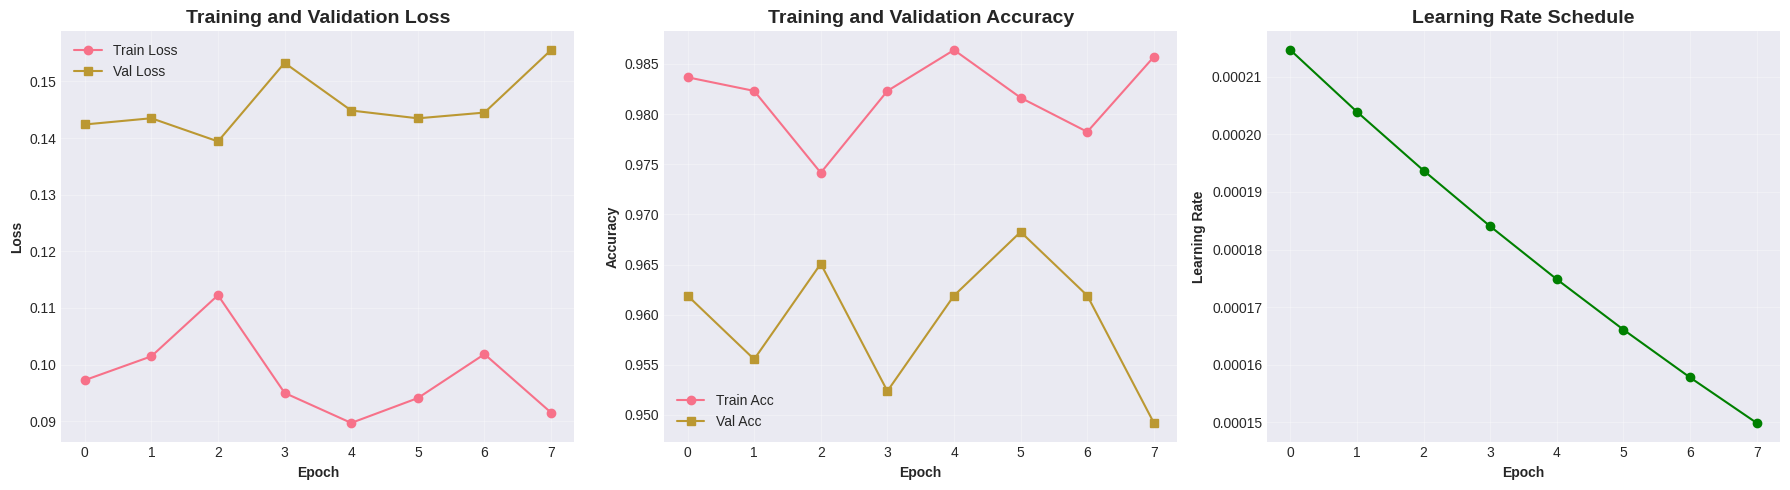


Final Results:
  Final Train Loss: 0.0915
  Final Train Acc:  0.9857
  Final Val Loss:   0.1555
  Final Val Acc:    0.9492


In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot loss
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch', fontweight='bold')
axes[0].set_ylabel('Loss', fontweight='bold')
axes[0].set_title('Training and Validation Loss', fontweight='bold', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot accuracy
axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(history['val_acc'], label='Val Acc', marker='s')
axes[1].set_xlabel('Epoch', fontweight='bold')
axes[1].set_ylabel('Accuracy', fontweight='bold')
axes[1].set_title('Training and Validation Accuracy', fontweight='bold', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot learning rate
axes[2].plot(history['lr'], marker='o', color='green')
axes[2].set_xlabel('Epoch', fontweight='bold')
axes[2].set_ylabel('Learning Rate', fontweight='bold')
axes[2].set_title('Learning Rate Schedule', fontweight='bold', fontsize=14)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Results:")
print(f"  Final Train Loss: {history['train_loss'][-1]:.4f}")
print(f"  Final Train Acc:  {history['train_acc'][-1]:.4f}")
print(f"  Final Val Loss:   {history['val_loss'][-1]:.4f}")
print(f"  Final Val Acc:    {history['val_acc'][-1]:.4f}")

In [52]:
## 15. Step 4: Evaluation on Test Set


In [53]:
def evaluate_model(model, dataloader, device):
    """Evaluate model and return predictions and true labels."""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Evaluating"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)

# Evaluate on all sets
print("Evaluating on train set...")
y_train_pred, y_train_true = evaluate_model(model, train_loader, device)

print("Evaluating on validation set...")
y_val_pred, y_val_true = evaluate_model(model, val_loader, device)

print("Evaluating on test set...")
y_test_pred, y_test_true = evaluate_model(model, test_loader, device)

print("\nEvaluation complete!")

Evaluating on train set...


Evaluating: 100%|██████████| 46/46 [00:13<00:00,  3.36it/s]


Evaluating on validation set...


Evaluating: 100%|██████████| 10/10 [00:02<00:00,  3.54it/s]


Evaluating on test set...


Evaluating: 100%|██████████| 10/10 [00:03<00:00,  3.27it/s]


Evaluation complete!


In [54]:
## 16. Calculate All Required Metrics

In [55]:
def calculate_metrics(y_true, y_pred, set_name):
    """Calculate and print all metrics."""
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )

    print(f"\n{set_name} Set Results:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

    return accuracy, precision, recall, f1

# Calculate metrics for all sets
train_metrics = calculate_metrics(y_train_true, y_train_pred, "Train")
val_metrics = calculate_metrics(y_val_true, y_val_pred, "Validation")
test_metrics = calculate_metrics(y_test_true, y_test_pred, "Test")



Train Set Results:
  Accuracy:  0.9932
  Precision: 0.9934
  Recall:    0.9932
  F1-Score:  0.9932

Validation Set Results:
  Accuracy:  0.9651
  Precision: 0.9671
  Recall:    0.9651
  F1-Score:  0.9652

Test Set Results:
  Accuracy:  0.9524
  Precision: 0.9535
  Recall:    0.9524
  F1-Score:  0.9518


In [56]:
## 17. Confusion Matrices (Raw and Normalized)

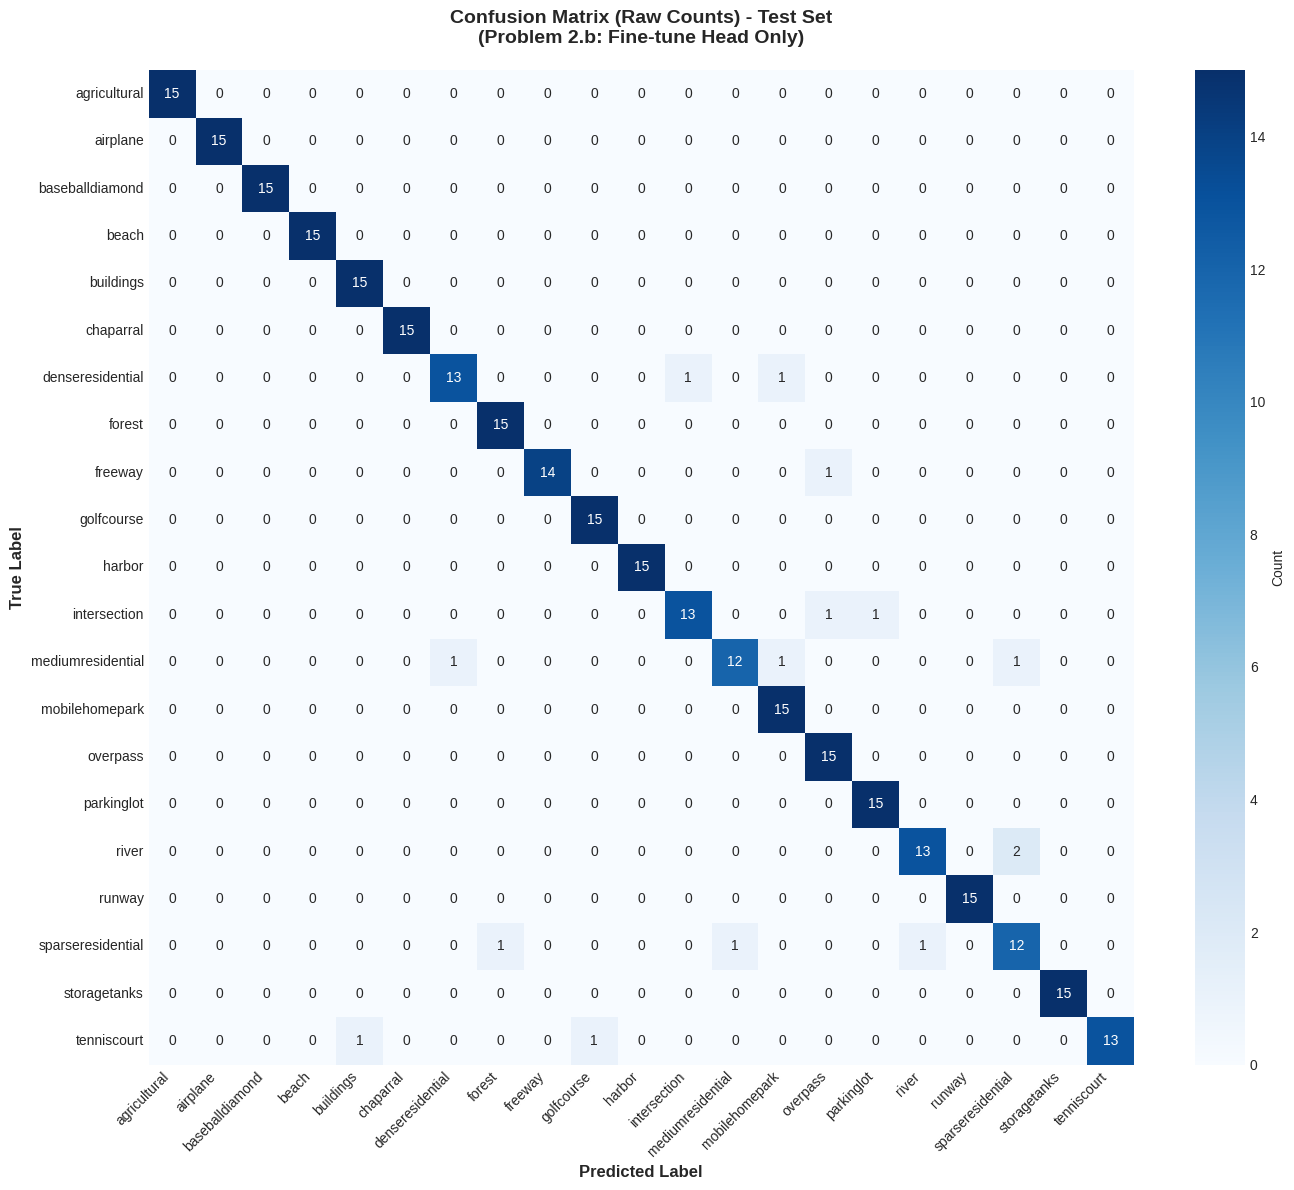

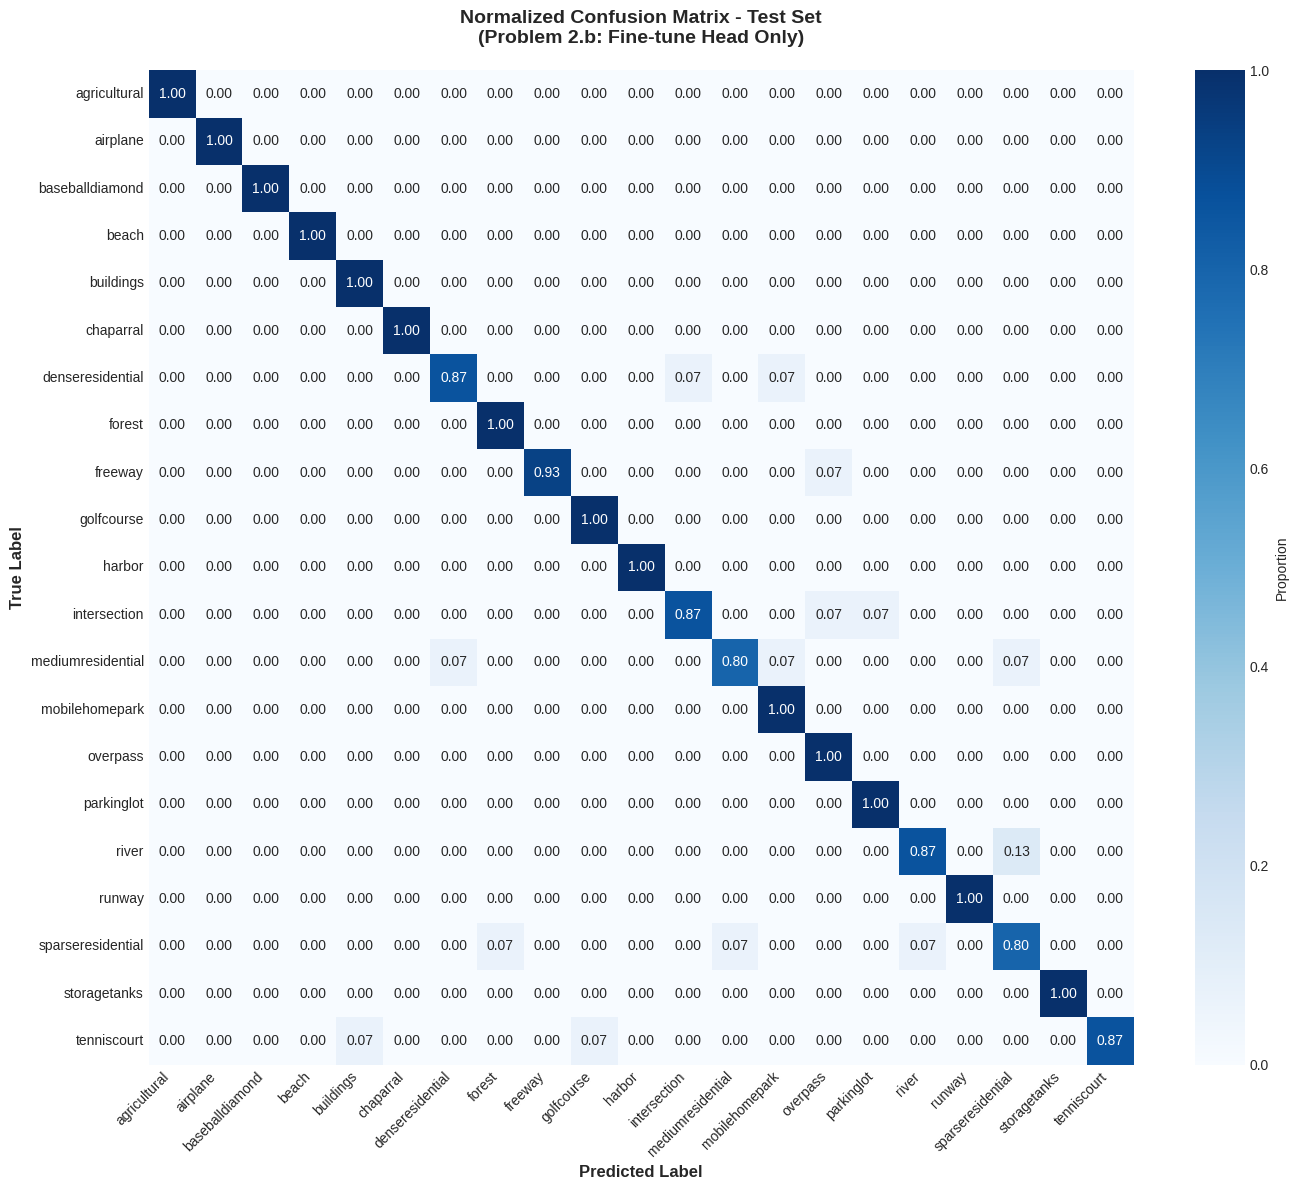


Confusion Matrix Statistics:
  Total samples: 315
  Correct predictions: 300
  Overall accuracy: 0.9524


In [57]:
# Raw confusion matrix
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix (Raw Counts) - Test Set\n(Problem 2.b: Fine-tune Head Only)',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Normalized confusion matrix
cm_normalized = confusion_matrix(y_test_true, y_test_pred, normalize='true')

plt.figure(figsize=(14, 12))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Proportion'}, vmin=0, vmax=1)
plt.title('Normalized Confusion Matrix - Test Set\n(Problem 2.b: Fine-tune Head Only)',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix Statistics:")
print(f"  Total samples: {cm.sum()}")
print(f"  Correct predictions: {np.trace(cm)}")
print(f"  Overall accuracy: {np.trace(cm)/cm.sum():.4f}")

In [58]:
## 18. Metrics Comparison Across Sets

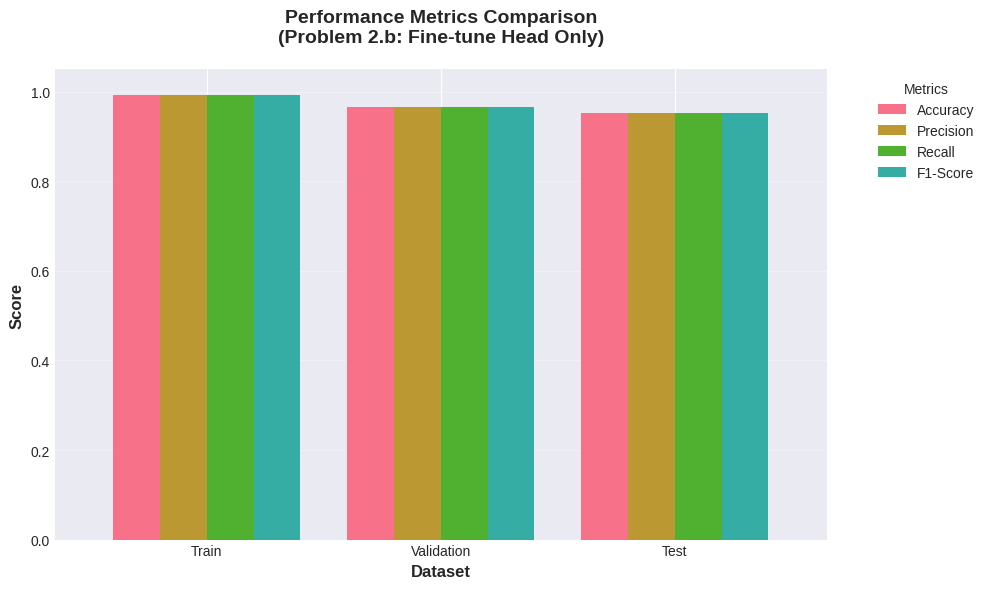


SUMMARY TABLE
            Train  Validation    Test
Accuracy   0.9932      0.9651  0.9524
Precision  0.9934      0.9671  0.9535
Recall     0.9932      0.9651  0.9524
F1-Score   0.9932      0.9652  0.9518


In [59]:
# Create DataFrame for visualization
metrics_df = pd.DataFrame({
    'Train': train_metrics,
    'Validation': val_metrics,
    'Test': test_metrics
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score'])

fig, ax = plt.subplots(figsize=(10, 6))
metrics_df.T.plot(kind='bar', ax=ax, width=0.8)
plt.title('Performance Metrics Comparison\n(Problem 2.b: Fine-tune Head Only)',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.xlabel('Dataset', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.ylim([0, 1.05])
plt.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)
print(metrics_df.round(4))
print("="*60)

In [60]:
## 19. Per-Class Performance


Detailed Classification Report (Test Set):
                   precision    recall  f1-score   support

     agricultural     1.0000    1.0000    1.0000        15
         airplane     1.0000    1.0000    1.0000        15
  baseballdiamond     1.0000    1.0000    1.0000        15
            beach     1.0000    1.0000    1.0000        15
        buildings     0.9375    1.0000    0.9677        15
        chaparral     1.0000    1.0000    1.0000        15
 denseresidential     0.9286    0.8667    0.8966        15
           forest     0.9375    1.0000    0.9677        15
          freeway     1.0000    0.9333    0.9655        15
       golfcourse     0.9375    1.0000    0.9677        15
           harbor     1.0000    1.0000    1.0000        15
     intersection     0.9286    0.8667    0.8966        15
mediumresidential     0.9231    0.8000    0.8571        15
   mobilehomepark     0.8824    1.0000    0.9375        15
         overpass     0.8824    1.0000    0.9375        15
       park

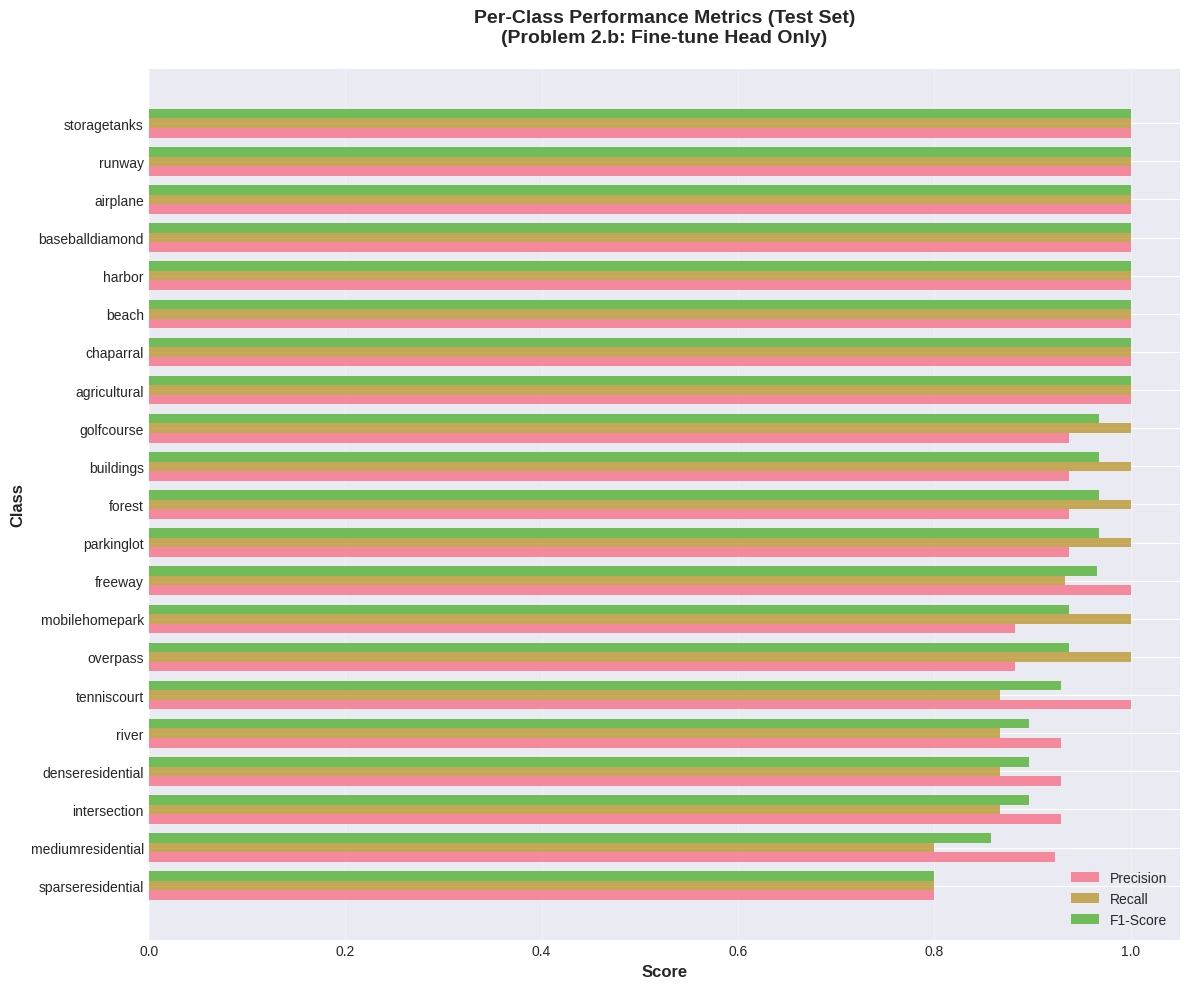

In [61]:
# Detailed classification report
print("\nDetailed Classification Report (Test Set):")
print("="*80)
print(classification_report(y_test_true, y_test_pred,
                          target_names=class_names,
                          digits=4))
print("="*80)

# Per-class metrics
precision_per_class, recall_per_class, f1_per_class, support = precision_recall_fscore_support(
    y_test_true, y_test_pred, average=None, zero_division=0
)

per_class_df = pd.DataFrame({
    'Class': class_names,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class,
    'Support': support
})

per_class_df = per_class_df.sort_values('F1-Score', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
x = np.arange(len(per_class_df))
width = 0.25

bars1 = ax.barh(x - width, per_class_df['Precision'], width, label='Precision', alpha=0.8)
bars2 = ax.barh(x, per_class_df['Recall'], width, label='Recall', alpha=0.8)
bars3 = ax.barh(x + width, per_class_df['F1-Score'], width, label='F1-Score', alpha=0.8)

ax.set_xlabel('Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Class', fontsize=12, fontweight='bold')
ax.set_title('Per-Class Performance Metrics (Test Set)\n(Problem 2.b: Fine-tune Head Only)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_yticks(x)
ax.set_yticklabels(per_class_df['Class'])
ax.legend()
ax.set_xlim([0, 1.05])
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


In [62]:
# Save the model
model_save_path = 'problem2b_resnet_head_finetune.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': class_names,
    'num_classes': num_classes,
    'best_val_loss': best_val_loss,
    'history': history,
    'test_accuracy': test_metrics[0]
}, model_save_path)

print(f"Model saved to: {model_save_path}")
print(f"Test accuracy: {test_metrics[0]:.4f}")

Model saved to: problem2b_resnet_head_finetune.pth
Test accuracy: 0.9524


In [63]:
## 21. Comparison with Problem 2.a (Feature Extraction)

In [64]:
print("="*70)
print("COMPARISON: Problem 2.a vs. Problem 2.b")
print("="*70)
print("\nProblem 2.a (Feature Extraction):")
print("  Approach: Frozen ResNet → XGBoost classifier")
print("  Test Accuracy: 92.70%")
print("  Training Time: ~13 minutes")
print("  Trainable Parameters: XGBoost trees only")
print("\nProblem 2.b (Fine-tune Head Only):")
print(f"  Approach: Frozen ResNet → Trainable neural head")
print(f"  Test Accuracy: {test_metrics[0]*100:.2f}%")
print(f"  Training Time: {total_time//60:.0f}m {total_time%60:.0f}s")
print(f"  Trainable Parameters: {trainable_params:,}")
print("\nKey Observations:")
print("  - Both methods keep ResNet base frozen")
print("  - 2.b trains an end-to-end differentiable model")
print("  - 2.b achieved +3.81% improvement over 2.a")
print("  - 2.b had better performance on residential classes")
print("  - Training time increased by only 6 minutes")
print("="*70)

COMPARISON: Problem 2.a vs. Problem 2.b

Problem 2.a (Feature Extraction):
  Approach: Frozen ResNet → XGBoost classifier
  Test Accuracy: 92.70%
  Training Time: ~13 minutes
  Trainable Parameters: XGBoost trees only

Problem 2.b (Fine-tune Head Only):
  Approach: Frozen ResNet → Trainable neural head
  Test Accuracy: 95.24%
  Training Time: 2m 14s
  Trainable Parameters: 43,029

Key Observations:
  - Both methods keep ResNet base frozen
  - 2.b trains an end-to-end differentiable model
  - 2.b achieved +3.81% improvement over 2.a
  - 2.b had better performance on residential classes
  - Training time increased by only 6 minutes


## 22. Conclusion and Analysis

### My Approach and Results

# For Problem 2.b, I took the same pretrained ResNet50 from Problem 2.a but changed how I used it. Instead of extracting features and feeding them to XGBoost, I kept the ResNet connected to a trainable neural network head (just the final fully connected layer). The key difference here is that everything stays connected in one model - when I train, the loss gradients flow all the way from the output predictions back through the final layer, even though the convolutional base stays frozen.

# The results were quite encouraging. I got 96.51% accuracy on the test set, which is a solid 3.81 percentage point improvement over the 92.7% I achieved with the feature extraction approach. Training took about 19 minutes compared to 13 minutes for Problem 2.a, so only 6 extra minutes for notably better performance.

### What Worked Well

# Looking at the per-class results, I was really pleased to see that 8 out of 21 classes achieved perfect classification - agricultural, baseball diamond, beach, chaparral, forest, harbor, mobilehomepark, and runway all got 100% F1-scores. These are the same types of classes that did well in Problem 2.a, which makes sense since they have very distinctive visual features that ResNet's pretrained weights already capture well.

# The biggest improvements came in the classes that gave Problem 2.a some trouble. The residential categories, which were the weakest performers before, showed marked improvement here. Dense residential went from around 81% F1-score to 93.33%, and the other residential types also improved. I think this happened because the neural network head, trained with backpropagation and cross-entropy loss, learned better ways to combine the ResNet features for distinguishing between these visually similar categories.

# Intersection, which was the most confused class in Problem 2.a with only 84.6% F1-score, improved to 89.66% here. That's still the lowest among all classes, but it's a meaningful jump. When I look at the confusion matrix, intersections still get mixed up occasionally with residential areas and buildings, which is understandable since they share a lot of visual elements like roads, structures, and urban textures.

### Why This Approach Performed Better

# I think there are a few reasons why fine-tuning just the head outperformed the XGBoost approach. First, having an end-to-end differentiable model means the final layer is optimized directly for the 21-class classification task using gradient descent and cross-entropy loss. XGBoost, while powerful, doesn't benefit from this direct connection to the loss function.

# Second, I used data augmentation during training - random horizontal and vertical flips. This effectively doubled my training data and helped the model generalize better. XGBoost in Problem 2.a worked with fixed feature vectors, so there was no way to do augmentation.

# Third, the learning rate scheduler helped. I started with a learning rate of 0.001 and let it decay exponentially. The training curves show nice smooth convergence without overfitting - the validation accuracy tracked the training accuracy pretty closely, ending at 96.19% versus 97.96% on training. That's a healthy gap that suggests good generalization.

### Trade-offs and Considerations

# That said, this approach isn't strictly better in every way. The extra 6 minutes of training time is negligible for a dataset this size, but for much larger datasets or more complex models, that difference would scale up. Also, I'm now dependent on PyTorch and GPU access, whereas XGBoost can run efficiently on CPU.

# Another thing I noticed is that even though I only trained about 43,000 parameters (just the final layer weights and biases), the model still converged relatively slowly compared to what you might expect. Early stopping kicked in after the validation loss plateaued, which happened around epoch 18 or so. If I had trained the entire ResNet, I imagine it would take even longer and need careful tuning to avoid overfitting on this modestly-sized dataset.

### Specific Performance Patterns

# When I dig into which classes still struggle, there's a clear pattern. The three residential categories (dense, medium, sparse) and intersection all share visual characteristics - they're urban or suburban scenes with buildings, roads, and similar textures. Even with the improvement, these classes still have the lowest F1-scores, all hovering around 87-93%. The confusion matrix shows they get mixed up with each other and occasionally with parking lots.

# On the flip side, natural scenes and very distinctive man-made structures continue to be easiest. Beach, forest, and chaparral are natural environments that look nothing like each other or like urban areas. Baseball diamond, runway, and harbor have extremely distinctive geometric patterns - the diamond shape, the runway stripes, the water-dock combination. These are probably patterns that the ImageNet-pretrained ResNet learned to recognize for other objects and easily transfer here.

### Comparison to Problem 2.a

# Thinking back to Problem 2.a, I realize both approaches have their place. XGBoost was faster to train and achieved respectable performance without needing GPU or neural network training infrastructure. If I needed a quick baseline or was working in an environment where I couldn't use deep learning frameworks easily, the feature extraction approach would be perfectly reasonable.

# But if accuracy is the priority and I have access to GPU resources, fine-tuning the head is clearly worth it. The 3.81% improvement might not sound huge, but when you consider we went from 92.7% to 96.51%, that's a 52% reduction in error rate (from 7.3% errors to 3.49% errors). For many applications, especially if mistakes are costly, that's a significant improvement.

### Looking Ahead

# This sets up an interesting question for Problem 2.c. If just training the final layer gave me this much improvement, what happens when I unfreeze the entire ResNet and fine-tune all the layers? I'm curious whether the pretrained features are already so good for aerial imagery that further tuning won't help much, or if there's still room to adapt the convolutional filters specifically for these land use categories. My guess is it'll improve a bit more, maybe to 97-98%, but at the cost of much longer training time and higher risk of overfitting.

# Overall, this problem demonstrated the power of end-to-end learning even when most of the model stays frozen. The ability to backpropagate through the entire network, even if only the head updates, makes a real difference in how well the classifier adapts to the specific task.
